# Laboratorio 7: Spark MLlib

## Inciso 8. Visualización y análisis de errores

**Equipo:** Abby Donis (22440), Hansel Lopez (19026), Fabian Prado (23427)

**Datos.** Se usan las predicciones de ambos modelos sobre 2026T1 (generadas en el inciso 7).

**Tarea.** Analizar el comportamiento de los errores: gráficos de real vs predicho, residuos, métricas por grupo y análisis por percentiles de salario.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import pandas as pd
from pyspark.ml import PipelineModel
from pyspark.sql import functions as F

from src import config, datos, modelos

config.preparar_directorios()
pd.set_option("display.float_format", "{:,.3f}".format)

spark = datos.iniciar_spark()
df_2026 = datos.cargar(spark, 2026)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


### 8.1 Cargar predicciones

Se cargan los modelos y se generan las predicciones sobre 2026T1. Se calcula el residuo como `real - predicho`: positivo significa subestimación, negativo significa sobreestimación.

In [2]:
modelo_lineal = PipelineModel.load(str(config.MODELOS / "regresion_lineal"))
modelo_rf = PipelineModel.load(str(config.MODELOS / "random_forest"))

pred_lineal = modelo_lineal.transform(df_2026).withColumn("residuo", F.col(config.OBJETIVO) - F.col("prediction")).cache()
pred_rf = modelo_rf.transform(df_2026).withColumn("residuo", F.col(config.OBJETIVO) - F.col("prediction")).cache()

### 8.2 Gráficos de real vs predicho

Scatter de salario real vs predicho con la línea y=x (predicción perfecta). Se usa una muestra de hasta 5,000 registros para que sea legible.

In [3]:
fraccion = min(1.0, 5000 / pred_lineal.count())
muestra_lineal = pred_lineal.sample(fraction=fraccion, seed=config.SEMILLA).limit(5000).toPandas()
muestra_rf = pred_rf.sample(fraction=fraccion, seed=config.SEMILLA).limit(5000).toPandas()
print(f"Muestra para gráficos: {len(muestra_lineal)} registros")

Muestra para gráficos: 5000 registros


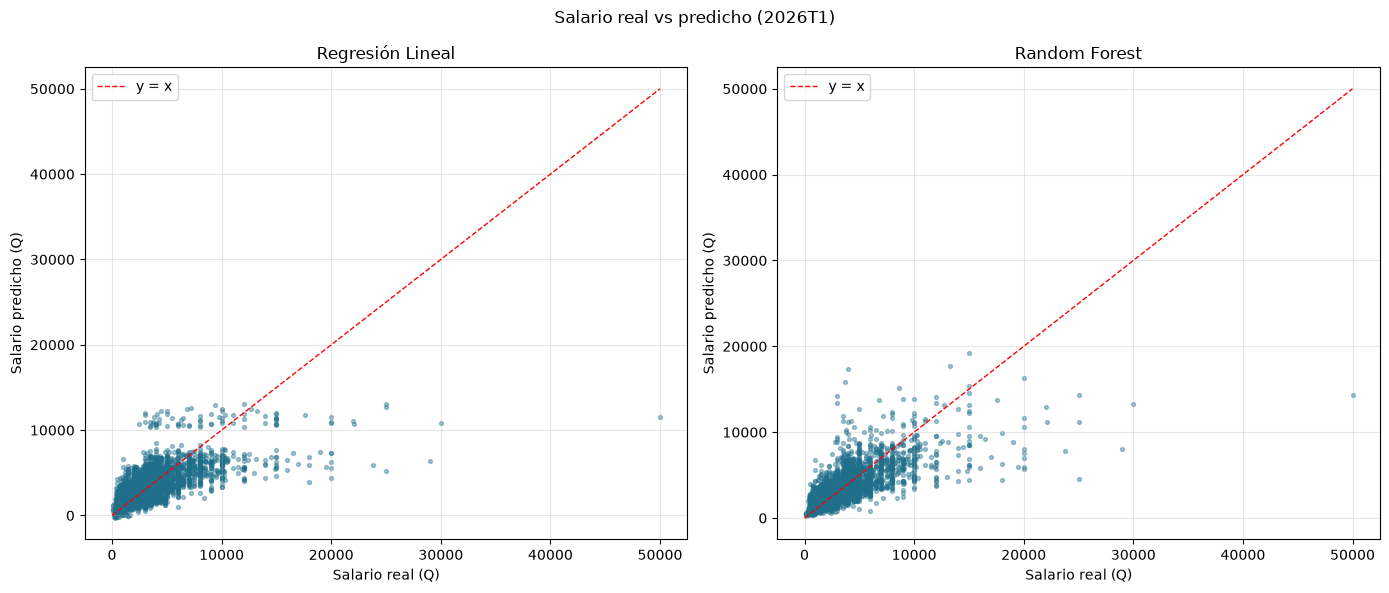

In [4]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 6))

for eje, muestra, titulo in zip(ejes, [muestra_lineal, muestra_rf],
                                ["Regresión Lineal", "Random Forest"]):
    eje.scatter(muestra[config.OBJETIVO], muestra["prediction"], s=8, alpha=0.4, color=config.COLORES["principal"])
    max_val = max(muestra[config.OBJETIVO].max(), muestra["prediction"].max())
    eje.plot([0, max_val], [0, max_val], "r--", linewidth=1, label="y = x")
    eje.set_xlabel("Salario real (Q)")
    eje.set_ylabel("Salario predicho (Q)")
    eje.set_title(titulo)
    eje.legend()
    eje.grid(alpha=0.3)

fig.suptitle("Salario real vs predicho (2026T1)")
fig.tight_layout()
fig.savefig(config.FIGURAS / "08_real_vs_predicho.png", dpi=120)
plt.show()

**Lectura.** Los puntos se agrupan cerca de la línea diagonal para salarios bajos y medios, pero para salarios altos las predicciones quedan por debajo de la línea (subestimación). Random Forest tiene puntos más pegados a la diagonal que la regresión lineal.

### 8.3 Gráficos de residuos

Scatter de residuos vs predicho con línea horizontal en cero. Un residuo positivo significa que el modelo subestimó, uno negativo significa que sobreestimó.

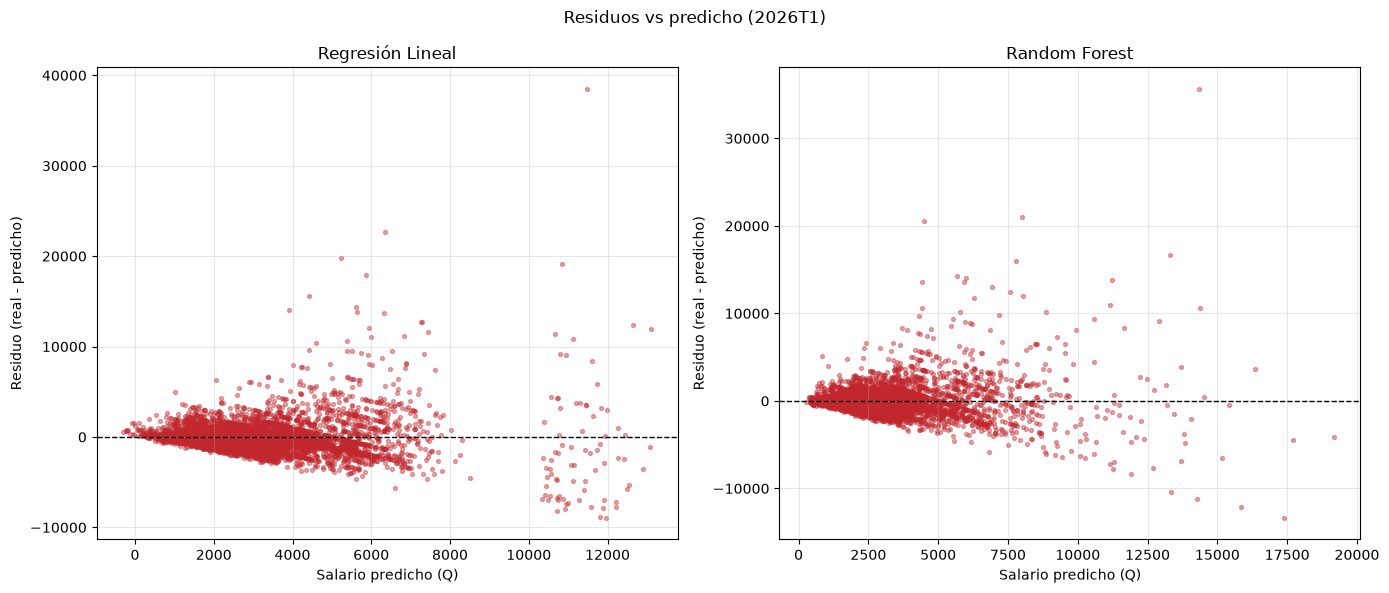

In [5]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 6))

for eje, muestra, titulo in zip(ejes, [muestra_lineal, muestra_rf],
                                ["Regresión Lineal", "Random Forest"]):
    eje.scatter(muestra["prediction"], muestra["residuo"], s=8, alpha=0.4, color=config.COLORES["modelo"])
    eje.axhline(0, color="black", linestyle="--", linewidth=1)
    eje.set_xlabel("Salario predicho (Q)")
    eje.set_ylabel("Residuo (real - predicho)")
    eje.set_title(titulo)
    eje.grid(alpha=0.3)

fig.suptitle("Residuos vs predicho (2026T1)")
fig.tight_layout()
fig.savefig(config.FIGURAS / "08_residuos.png", dpi=120)
plt.show()

**Lectura.** Los residuos se dispersan más para predicciones altas. Hay una tendencia a residuos positivos grandes (subestimación) para salarios altos, lo que confirma que los modelos no alcanzan los salarios más altos. Random Forest tiene menor dispersión.

### 8.4 Métricas por grupo

Se calculan MAE y error medio por nivel educativo y por dominio, usando **todos** los registros de prueba (no solo la muestra).

In [6]:
def metricas_por_grupo(pred, grupo):
    """MAE, error medio y n por grupo."""
    return (pred.withColumn("error_abs", F.abs(F.col("residuo")))
            .groupBy(grupo)
            .agg(F.count("*").alias("n"),
                 F.mean("error_abs").alias("mae"),
                 F.mean("residuo").alias("error_medio"))
            .orderBy(grupo)
            .toPandas())


def etiquetar(df_tabla, columna):
    """Traduce códigos a etiquetas legibles."""
    df_tabla[columna] = df_tabla[columna].map(config.ETIQUETAS.get(columna, lambda x: x))
    return df_tabla

In [7]:
print("=== Regresión Lineal por nivel educativo ===")
tabla_lineal_edu = metricas_por_grupo(pred_lineal, "nivel_educativo")
etiquetar(tabla_lineal_edu, "nivel_educativo")

=== Regresión Lineal por nivel educativo ===


,nivel_educativo,n,mae,error_medio
0,Ninguno,1016,824.467,135.753
1,Preprimaria,80,736.031,107.425
2,Primaria,3957,869.930,70.107
3,Basico,2164,896.023,149.526
4,Diversificado,4117,"1,109.638",123.171
5,Superior,1729,"2,554.064",353.897
6,Maestria,183,"5,523.266",4.933
7,Doctorado,12,"13,002.141","6,680.386"


In [8]:
print("=== Random Forest por nivel educativo ===")
tabla_rf_edu = metricas_por_grupo(pred_rf, "nivel_educativo")
etiquetar(tabla_rf_edu, "nivel_educativo")

=== Random Forest por nivel educativo ===


,nivel_educativo,n,mae,error_medio
0,Ninguno,1016,633.271,82.892
1,Preprimaria,80,557.803,39.144
2,Primaria,3957,752.948,77.129
3,Basico,2164,805.283,155.194
4,Diversificado,4117,"1,012.046",112.124
5,Superior,1729,"2,269.638",283.899
6,Maestria,183,"4,731.150",-166.480
7,Doctorado,12,"11,656.288","6,122.179"


In [9]:
print("=== Regresión Lineal por dominio ===")
tabla_lineal_dom = metricas_por_grupo(pred_lineal, "dominio")
etiquetar(tabla_lineal_dom, "dominio")

=== Regresión Lineal por dominio ===


,dominio,n,mae,error_medio
0,Urbano metropolitano,5632,"1,443.751",172.647
1,Resto urbano,4846,"1,188.525",152.226
2,Rural nacional,2780,913.017,85.438


In [10]:
print("=== Random Forest por dominio ===")
tabla_rf_dom = metricas_por_grupo(pred_rf, "dominio")
etiquetar(tabla_rf_dom, "dominio")

=== Random Forest por dominio ===


,dominio,n,mae,error_medio
0,Urbano metropolitano,5632,"1,313.370",185.018
1,Resto urbano,4846,"1,033.494",102.991
2,Rural nacional,2780,755.876,65.738


**Lectura.**

- **Por nivel educativo:** el MAE es mayor para niveles educativos altos (maestría, doctorado), lo que tiene sentido porque sus salarios son más altos y variables. El error medio es positivo (subestimación) para todos los grupos, pero más marcado en los niveles altos.
- **Por dominio:** el MAE es similar entre dominios, con una ligera ventaja del área urbana metropolitana. El error medio es positivo en todos, indicando subestimación general.

### 8.5 Análisis por percentiles de salario

Se divide los registros en deciles por salario real y se calcula el MAE y error medio en cada decil. Esto muestra si los errores son mayores en salarios altos.

In [11]:
def metricas_por_decil(pred):
    """MAE y error medio por decil de salario real."""
    with_decil = pred.withColumn("decil", F.ntile(10).over(
        __import__("pyspark").sql.Window.orderBy(config.OBJETIVO)))
    return (with_decil.withColumn("error_abs", F.abs(F.col("residuo")))
            .groupBy("decil")
            .agg(F.count("*").alias("n"),
                 F.mean(config.OBJETIVO).alias("salario_medio"),
                 F.mean("error_abs").alias("mae"),
                 F.mean("residuo").alias("error_medio"))
            .orderBy("decil")
            .toPandas())


deciles_lineal = metricas_por_decil(pred_lineal)
deciles_rf = metricas_por_decil(pred_rf)

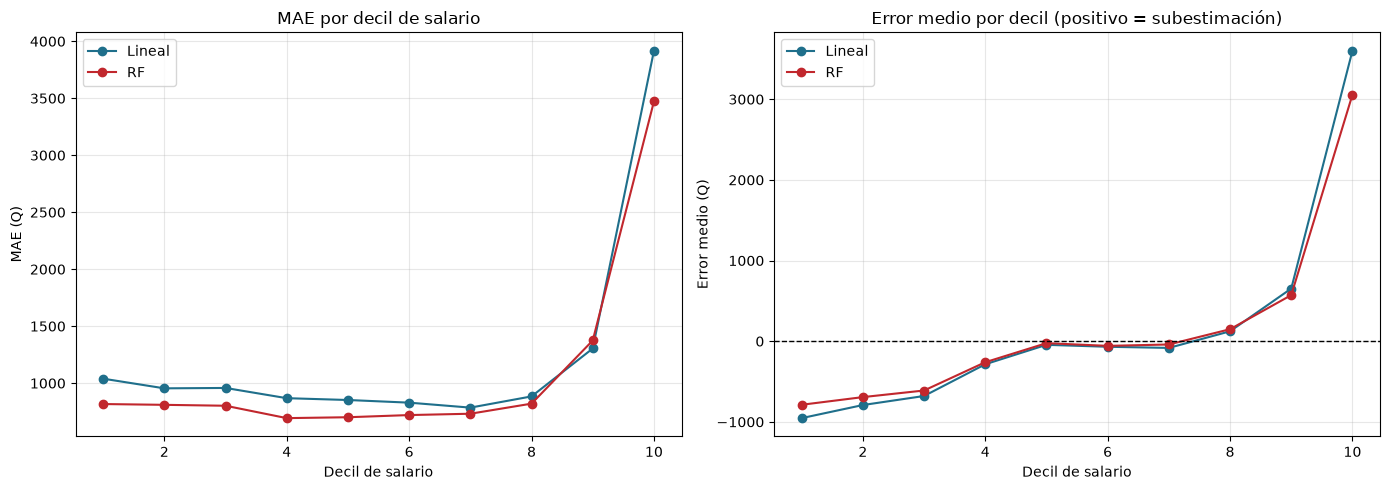

In [12]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

ejes[0].plot(deciles_lineal["decil"], deciles_lineal["mae"], marker="o", label="Lineal", color=config.COLORES["principal"])
ejes[0].plot(deciles_rf["decil"], deciles_rf["mae"], marker="o", label="RF", color=config.COLORES["modelo"])
ejes[0].set_xlabel("Decil de salario")
ejes[0].set_ylabel("MAE (Q)")
ejes[0].set_title("MAE por decil de salario")
ejes[0].legend()
ejes[0].grid(alpha=0.3)

ejes[1].plot(deciles_lineal["decil"], deciles_lineal["error_medio"], marker="o", label="Lineal", color=config.COLORES["principal"])
ejes[1].plot(deciles_rf["decil"], deciles_rf["error_medio"], marker="o", label="RF", color=config.COLORES["modelo"])
ejes[1].axhline(0, color="black", linestyle="--", linewidth=1)
ejes[1].set_xlabel("Decil de salario")
ejes[1].set_ylabel("Error medio (Q)")
ejes[1].set_title("Error medio por decil (positivo = subestimación)")
ejes[1].legend()
ejes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(config.FIGURAS / "08_deciles.png", dpi=120)
plt.show()

**Lectura.**

- El MAE crece con el decil: los errores son mucho mayores en salarios altos. Esto es esperable porque los salarios altos son más dispersos y los modelos tienden a predecir valores más conservadores.
- El error medio es positivo en todos los deciles, pero se dispara en los deciles altos (subestimación). En los deciles bajos el error medio es cercano a cero o ligeramente negativo (sobreestimación).
- Random Forest tiene menor MAE en todos los deciles, especialmente en los altos.

### 8.6 Discusión final

**Hallazgos principales:**

1. **Random Forest supera a la regresión lineal** en todos los periodos (2025T4 y 2026T1). Captura interacciones y no linealidades que el modelo lineal no puede.

2. **Subestimación de salarios altos.** Ambos modelos tienden a subestimar los salarios más altos. El 1% de salarios más altos aporta una parte desproporcionada del error cuadrático. Esto es consistente con lo visto en el inciso 5.

3. **El error crece con el nivel de salario.** Los deciles altos tienen MAE mucho mayor que los bajos. Los modelos predicen valores más conservadores y no alcanzan los salarios extremos.

4. **La educación es el predictor más importante.** Tanto en la regresión lineal como en Random Forest, las variables educativas (especialmente maestría y doctorado) son las que más se asocian con el salario.

5. **Los modelos generalizan bien.** Las métricas en 2026T1 son similares a las de 2025T4, lo que indica que los patrones aprendidos son estables.

6. **Limitaciones.** El 48% de la variación del salario (R2 de RF) queda sin explicar. Factores como la ocupación específica, la rama de actividad o el tamaño de la empresa no están en los datos y podrían mejorar el modelo.

**Conclusión.** Los modelos son útiles para estimar salarios de forma agregada, pero tienen limitaciones para predecir salarios individuales, especialmente los más altos. Random Forest es la mejor opción por su menor error y capacidad de capturar interacciones.

In [13]:
spark.stop()